In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("winequality-red.csv")
df.head(5)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [2]:
# Recuento de valores faltantes por columna
missing_per_column = df.isnull().sum()

# Total de valores faltantes en todo el dataset
total_missing = df.isnull().sum().sum()



In [3]:
print("Valores faltantes por columna:\n")
print(missing_per_column)

print("\nTotal de valores faltantes en el dataset:", total_missing)

Valores faltantes por columna:

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total de valores faltantes en el dataset: 0


Una vez visto que en el dataset no hay valores faltantes ni nada podemos pasar a ver las distribuciones de las variables que tenemos e incluso ver los estadísticos descriptivos que nos interesan de este dataset.

In [5]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


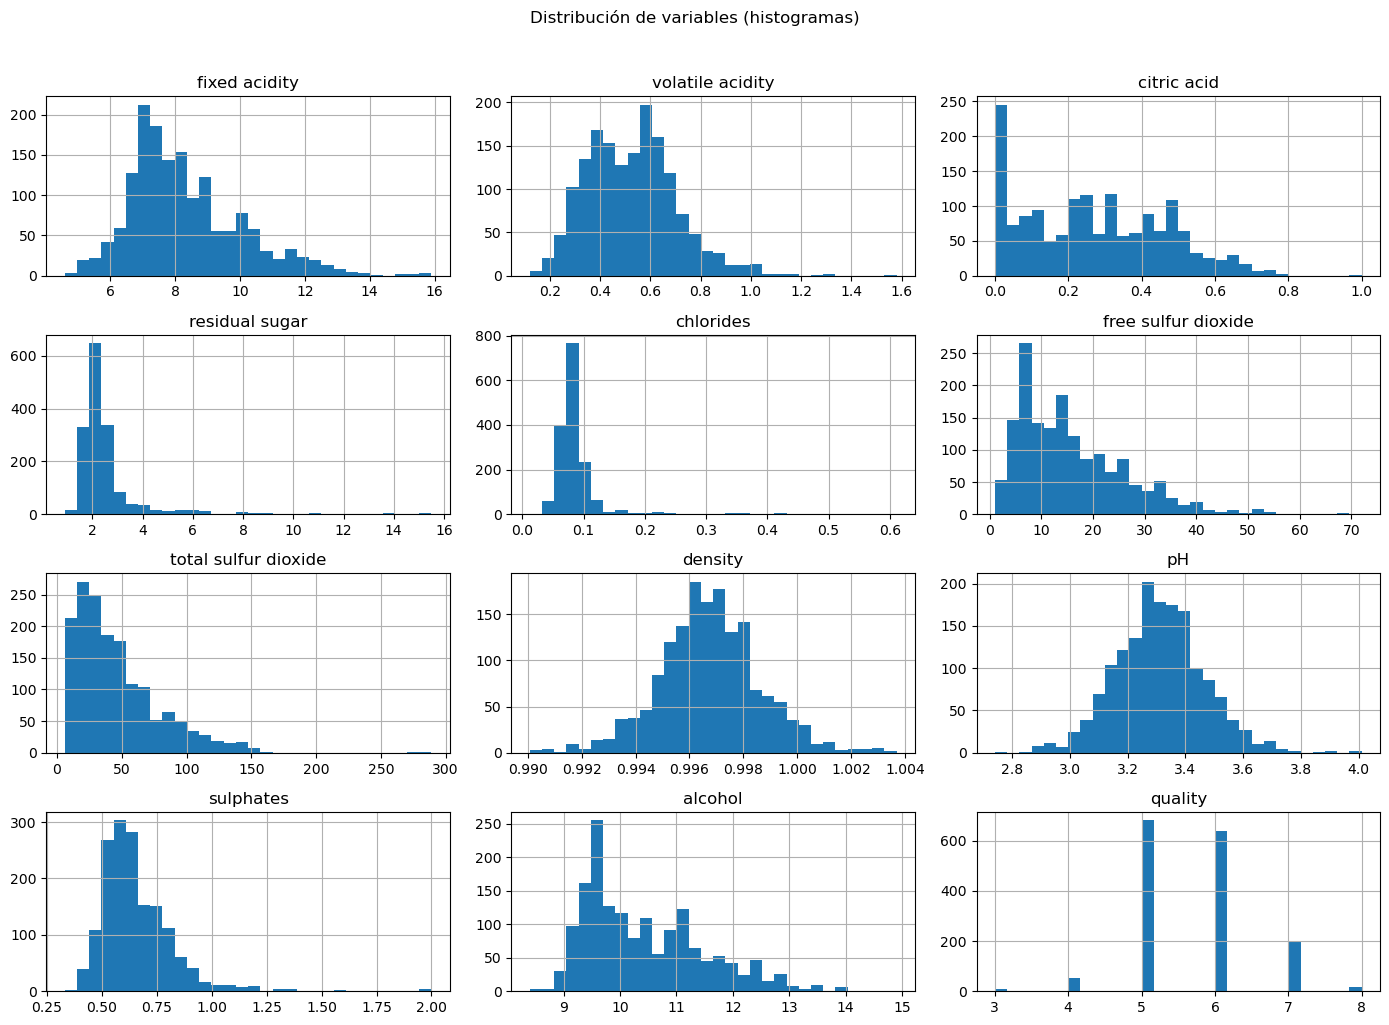

In [6]:
# Histogramas para todas las columnas numéricas
df.hist(bins=30, figsize=(14, 10))
plt.suptitle("Distribución de variables (histogramas)", y=1.02)
plt.tight_layout()
plt.show()

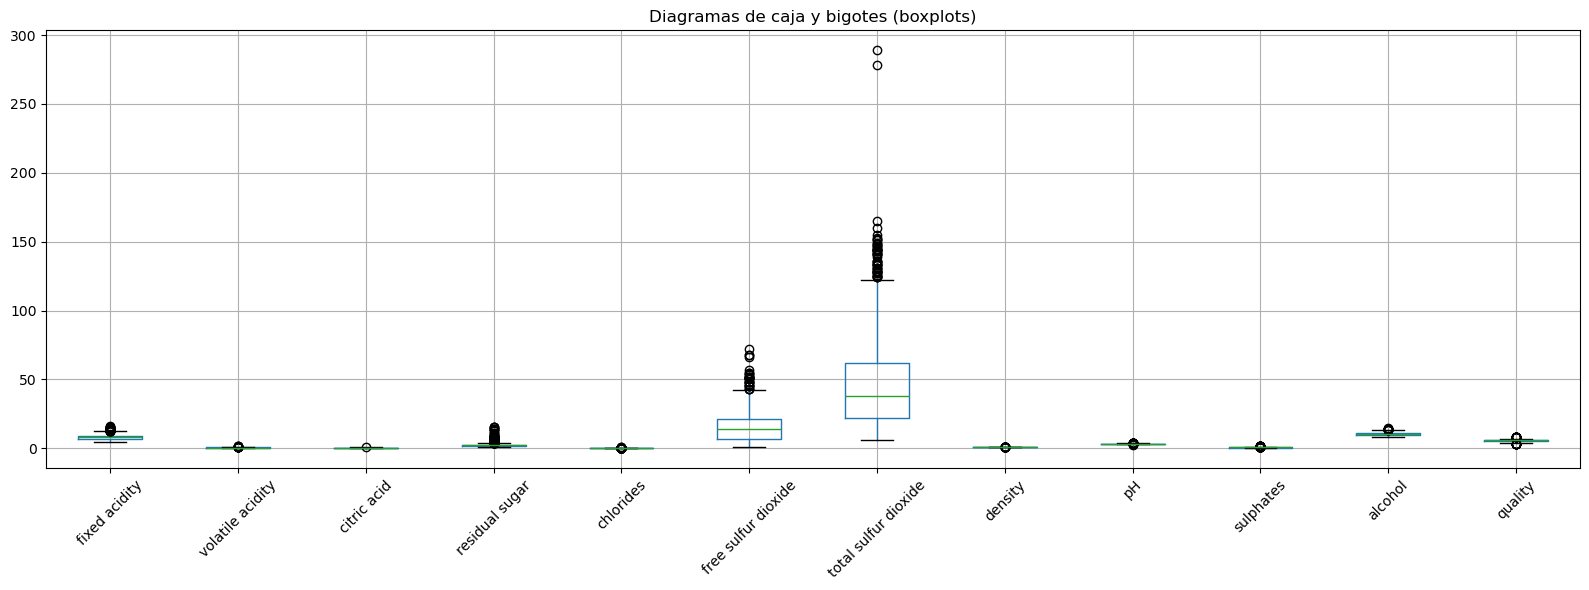

In [7]:
# Boxplot de todas las variables numéricas
df.boxplot(figsize=(16, 6), rot=45)
plt.title("Diagramas de caja y bigotes (boxplots)")
plt.tight_layout()
plt.show()

Podemos ver que hay varias variables que tienen sus datos sesgados hacia la izquierda mientras que otras están centradas. También podemos ver que la variable de calidad la podemos transformar a una variable categórica ya que toma valores discretos y finitos por tanto cuando vaya a realizar una clasificación usaremos esta variable para ver como se comportan los distintos tipos de clasificadores que conocemos.

In [9]:
# Convertir quality a variable categórica
df["quality_cat"] = df["quality"].astype("category")

Una vez hecha esta transformación vamos a pasar a intentar primero usar modelos de regresión para predecir la variable fixed acidity.

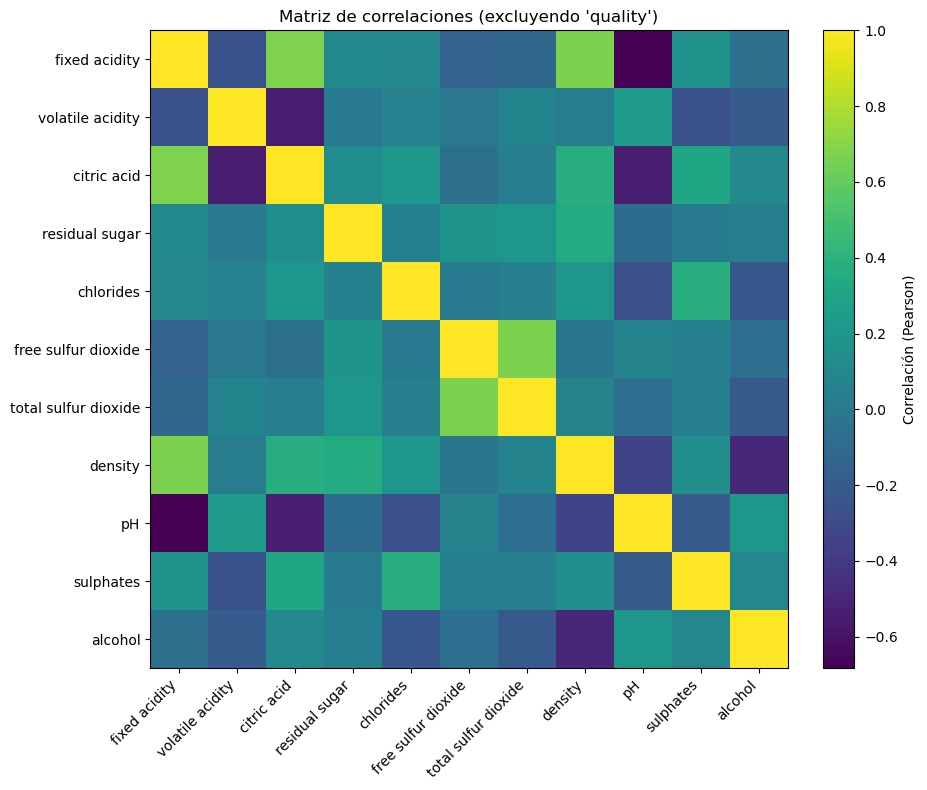

In [11]:
df_corr = df.drop(columns=["quality", "quality_cat", "null_count"], errors="ignore")
# Solo columnas numéricas (por seguridad)
df_corr = df_corr.select_dtypes(include=[np.number])
# Correlación de Pearson
corr = df_corr.corr()

# Plot con matplotlib (sin seaborn)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values)

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Correlación (Pearson)")

ax.set_title("Matriz de correlaciones (excluyendo 'quality')")
plt.tight_layout()
plt.show()

Antes de intentar predecir podemos mirar cuan relacionadas están las variables numéricas con nuestra variable target, a simple vista podemos ver que fixed acidity está bastante relacionada con density, citric acid y ph. Esto nos puede ayudar mucho a la hora de si tuviesemos que escoger unas variables que la tuvieran que explicar cogerlas a ellas. 

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1) Target y features (incluimos quality como predictor)
y = df["fixed acidity"]
X = df.drop(columns=["fixed acidity"], errors="ignore")  # NO quitamos quality

# 2) Columnas numéricas y categóricas
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(exclude=["number"]).columns.tolist()  # aquí caerá 'quality' (category)

# 3) Preprocesado: escalar numéricas + one-hot en categóricas
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

# 4) Pipeline (solo preprocesado por ahora; luego añadimos el modelo)
pipeline = Pipeline(steps=[
    ("preprocess", preprocess)
])

# 5) Train/Test split 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print("Shapes:")
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)
print("\nNum cols:", len(num_cols), "Cat cols:", len(cat_cols), "Categóricas:", cat_cols)


Shapes:
X_train: (1119, 12) X_test: (480, 12)
y_train: (1119,) y_test: (480,)

Num cols: 11 Cat cols: 1 Categóricas: ['quality_cat']


Comenzamos con la regresión una vez tenemos todo eso hecho. Vamos a comenzar con la regresión múltiple y vemos sus resultados.

Vamos a ver primero si los residuos son normales y cumplen que tengan varianza constante y media 0.

Media de residuos (test): 0.015140882118821145
Varianza de residuos (test): 0.3452116212243907


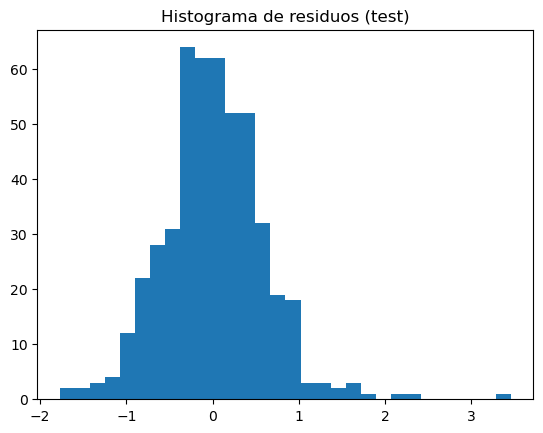

<Figure size 640x480 with 0 Axes>

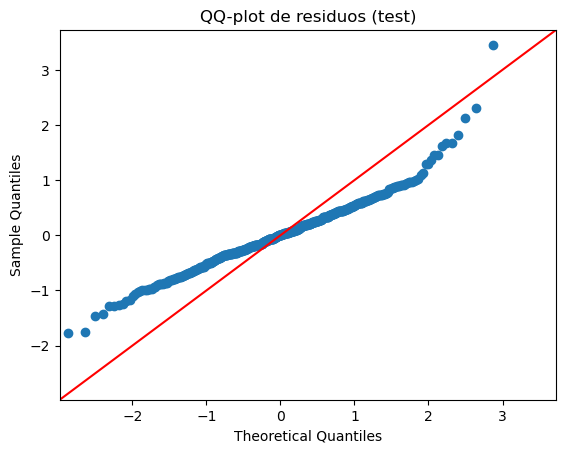

Shapiro p-value (aprox): 4.759006570451108e-08


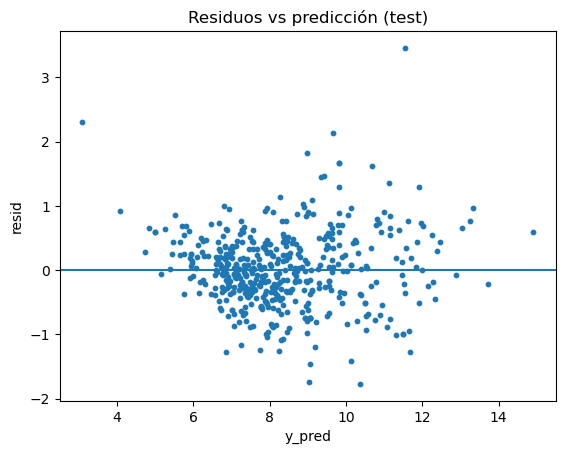

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

# Predicciones y residuos (en test)
y_pred = linreg_pipe.predict(X_test)
resid = y_test.to_numpy() - y_pred

print("Media de residuos (test):", resid.mean())
print("Varianza de residuos (test):", resid.var(ddof=1))

# 1) Histograma + QQ plot (normalidad aproximada)
plt.figure()
plt.hist(resid, bins=30)
plt.title("Histograma de residuos (test)")
plt.show()

plt.figure()
sm.qqplot(resid, line="45")
plt.title("QQ-plot de residuos (test)")
plt.show()

# Test de normalidad (Shapiro; ojo: con N grande casi siempre rechaza)
shapiro_p = stats.shapiro(resid[:5000] if len(resid) > 5000 else resid).pvalue
print("Shapiro p-value (aprox):", shapiro_p)

# 2) Residuos vs predicción (homocedasticidad / no linealidad)
plt.figure()
plt.scatter(y_pred, resid, s=10)
plt.axhline(0)
plt.title("Residuos vs predicción (test)")
plt.xlabel("y_pred")
plt.ylabel("resid")
plt.show()


In [77]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Matriz transformada (la misma que usa el modelo del pipeline)
Xtr = preprocess.transform(X_train)
Xtr = np.asarray(Xtr)

# OLS sobre features transformadas
Xtr_const = sm.add_constant(Xtr, has_constant="add")
ols_sm = sm.OLS(y_train.to_numpy(), Xtr_const).fit()

# Breusch–Pagan
bp = het_breuschpagan(ols_sm.resid, ols_sm.model.exog)
print("Breusch–Pagan p-value:", bp[1])  # si es pequeño -> heterocedasticidad


Breusch–Pagan p-value: 5.568995115863854e-15


Podemos ver que los residuos no tienen media exactamente 0, eso no es un drama ya que esta cerca. Pero, podemos ver que en el gráfico QQ se tiene que las colas no se mantienen en la recta lo que indica cierta asimetría. Eso ya nos indica que no siguen una normal, pero para más inri podemos ver que los residuos tienen como forma de abanico y esto nos lo confirma Breusch-Pagan con el p-value, por tanto deducimos que hay heterocedasticidad. La conclusión de todo esto es que en la hora de hacer regresión no nos afecta, pero si quisieramos hacer inferencia estos serían problemas graves que deberíamos resolver.

In [45]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 7) Pipeline + Linear Regression
linreg_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

linreg_pipe.fit(X_train, y_train)
y_pred = linreg_pipe.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE (test): {rmse:.4f}")
print(f"R^2 (test):  {r2:.4f}")

# 8) Coeficientes con nombres (post-transform)
pre = linreg_pipe.named_steps["preprocess"]

# nombres numéricos
num_feature_names = num_cols

# nombres one-hot
cat_feature_names = []
if len(cat_cols) > 0:
    ohe = pre.named_transformers_["cat"]
    cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()

feature_names = num_feature_names + cat_feature_names

coefs = linreg_pipe.named_steps["model"].coef_
intercept = linreg_pipe.named_steps["model"].intercept_

coef_table = pd.DataFrame({"feature": feature_names, "coef": coefs})
coef_table["abs_coef"] = coef_table["coef"].abs()
coef_table = coef_table.sort_values("abs_coef", ascending=False).drop(columns="abs_coef")

print("\nIntercepto:", intercept)
print("\nCoeficientes (ordenados por |coef|):")
print(coef_table.to_string(index=False))



RMSE (test): 0.5871
R^2 (test):  0.8939

Intercepto: 8.38877803653941

Coeficientes (ordenados por |coef|):
             feature      coef
             density  1.210743
                  pH -0.821702
             alcohol  0.570233
      residual sugar -0.387650
         citric acid  0.364775
           quality_3  0.270863
total sulfur dioxide -0.195219
           quality_8 -0.180767
           chlorides -0.158126
           sulphates -0.142274
           quality_5 -0.134326
 free sulfur dioxide  0.105296
           quality_6 -0.080416
           quality_7  0.069668
    volatile acidity  0.055573
           quality_4  0.054979


Podemos ver que el RMSE es bastante pequeño, eso es bueno, ya que fixed_acidity se mueve entorno a las unidades y decenas. Además podemos ver que el R^2 es casi 0.9 lo cual nos dice que este modelo simple explica bastante bien y predice bien a la variable

Ahora vamos a aplicar el método de StepWise, para ver si mejora o no al OLS de toda la vida.

In [47]:
import pandas as pd
import numpy as np

import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# -------------------------
# 3) Stepwise (Forward Selection) por p-valor
# -------------------------
def forward_stepwise_ols(X_df: pd.DataFrame, y_series: pd.Series, alpha_in: float = 0.05):
    remaining = list(X_df.columns)
    selected = []
    steps = []

    # intercepto solo
    current_X = sm.add_constant(pd.DataFrame(index=X_df.index), has_constant="add")
    current_model = sm.OLS(y_series.values, current_X.values).fit()

    while True:
        best_var = None
        best_p = np.inf
        best_ci = None
        best_model = None

        for var in remaining:
            trial_vars = selected + [var]
            trial_X = sm.add_constant(X_df[trial_vars], has_constant="add")
            model = sm.OLS(y_series.values, trial_X.values).fit()

            # p-valor de la variable recién añadida (índice: 1+posición)
            # Usamos el vector de nombres para localizarlo de forma robusta
            names = ["const"] + trial_vars
            pvals = pd.Series(model.pvalues, index=names)
            pval = float(pvals[var])

            if pval < best_p:
                best_p = pval
                best_var = var
                best_model = model

                ci_arr = model.conf_int()
                ci = pd.DataFrame(ci_arr, index=names, columns=["low", "high"]).loc[var].tolist()
                best_ci = ci

        if best_var is not None and best_p < alpha_in:
            selected.append(best_var)
            remaining.remove(best_var)
            steps.append({
                "step": len(selected),
                "entered": best_var,
                "p_value": best_p,
                "ci_low": best_ci[0],
                "ci_high": best_ci[1],
                "contains_0": (best_ci[0] <= 0 <= best_ci[1])
            })
            current_model = best_model
        else:
            break

    return selected, pd.DataFrame(steps), current_model

selected_vars, steps_df, final_model = forward_stepwise_ols(X_train_scaled, y_train, alpha_in=0.05)

# -------------------------
# 4) Mostrar orden de entrada con IC y p-valor
# -------------------------
print("===== STEPWISE (Forward selection, p<0.05) =====")
if steps_df.empty:
    print("No entró ninguna variable con el umbral de significación elegido.")
else:
    steps_df_display = steps_df.copy()
    steps_df_display["p_value"] = steps_df_display["p_value"].map(lambda x: f"{x:.3e}")
    steps_df_display["ci_low"] = steps_df_display["ci_low"].map(lambda x: f"{x:.4f}")
    steps_df_display["ci_high"] = steps_df_display["ci_high"].map(lambda x: f"{x:.4f}")
    print("\nOrden de entrada (para cada variable: p-valor e IC 95%):\n")
    print(steps_df_display.to_string(index=False))

# -------------------------
# 5) Coefs finales (con IC y p-valor)
# -------------------------
if not steps_df.empty:
    # reconstruir nombres
    names = ["const"] + selected_vars

    params = pd.Series(final_model.params, index=names)
    pvals = pd.Series(final_model.pvalues, index=names)
    ci = pd.DataFrame(final_model.conf_int(), index=names, columns=["ci_low", "ci_high"])

    coef_table = pd.DataFrame({
        "coef": params,
        "p_value": pvals,
        "ci_low": ci["ci_low"],
        "ci_high": ci["ci_high"],
    })
    coef_table["contains_0"] = (coef_table["ci_low"] <= 0) & (coef_table["ci_high"] >= 0)

    # formateo
    coef_table_fmt = coef_table.copy()
    coef_table_fmt["coef"] = coef_table_fmt["coef"].map(lambda x: f"{x:.4f}")
    coef_table_fmt["p_value"] = coef_table_fmt["p_value"].map(lambda x: f"{x:.3e}")
    coef_table_fmt["ci_low"] = coef_table_fmt["ci_low"].map(lambda x: f"{x:.4f}")
    coef_table_fmt["ci_high"] = coef_table_fmt["ci_high"].map(lambda x: f"{x:.4f}")

    print("\n\n===== MODELO FINAL (variables seleccionadas) =====")
    print("Variables seleccionadas:", selected_vars)
    print("\nCoeficientes (IC 95% y p-valor):\n")
    print(coef_table_fmt.to_string())

    # -------------------------
    # 6) Métricas en test
    # -------------------------
    X_test_final = sm.add_constant(X_test_scaled[selected_vars], has_constant="add")
    y_pred_test = final_model.predict(X_test_final.values)

    rmse = float(np.sqrt(np.mean((y_test.values - y_pred_test) ** 2)))
    r2 = float(1 - np.sum((y_test.values - y_pred_test) ** 2) / np.sum((y_test.values - y_test.values.mean()) ** 2))

    print("\n\n===== EVALUACIÓN EN TEST =====")
    print(f"RMSE (test): {rmse:.4f}")
    print(f"R^2 (test):  {r2:.4f}")
else:
    print("\nNo hay modelo final porque no se seleccionaron variables.")


===== STEPWISE (Forward selection, p<0.05) =====

Orden de entrada (para cada variable: p-valor e IC 95%):

 step              entered    p_value  ci_low ci_high  contains_0
    1                   pH 1.259e-151 -1.2358 -1.0880       False
    2              density 5.434e-122  0.7716  0.8939       False
    3              alcohol  3.980e-97  0.5826  0.6905       False
    4       residual sugar  2.050e-59 -0.4647 -0.3699       False
    5          citric acid  1.055e-18  0.1969  0.3068       False
    6            sulphates  3.623e-20 -0.2412 -0.1578       False
    7            chlorides  8.936e-10 -0.1813 -0.0939       False
    8 total sulfur dioxide  3.956e-10 -0.1715 -0.0902       False
    9  free sulfur dioxide  2.070e-04  0.0465  0.1502       False
   10            quality_7  2.228e-02  0.0213  0.2774       False
   11     volatile acidity  1.433e-02  0.0127  0.1144       False


===== MODELO FINAL (variables seleccionadas) =====
Variables seleccionadas: ['pH', 'density', 'alc

Como podemos ver el modelo es el mismo, ya que como podemos ver todas las variables entran a la regresión ya que su nivel de significancia es el suficiente, lo podemos ver viendo que ningún IC contiene al 0 en su intervalo y sus p-value son todos menores que en este caso 0.05. Y como es obvio podemos ver que el RMSE y el R^2 es el mismo que en OLS.

Ahora vamos a aplicar mínimos cuadrados recortados para ver como funcionarían en este modelo, aun que como no hay muchos outliers, por no decir que no hay ninguno, seguramente empeore al OLS normal.

In [49]:
import numpy as np
import random
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Transformar con el mismo preprocess que ya tienes (OHE + StandardScaler)
Xtr = preprocess.fit_transform(X_train, y_train)
Xte = preprocess.transform(X_test)

# Por si salen matrices dispersas
Xtr = np.asarray(Xtr)
Xte = np.asarray(Xte)
ytr = np.asarray(y_train)
yte = np.asarray(y_test)

def LTS(X, y, porcentaje_n=0.8, rep=50, rep2=200, seed=42):
    """
    LTS estilo 'tu código':
    - Escoge subconjunto aleatorio de tamaño n = porcentaje_n * N
    - Ajusta LinearRegression y usa score (R^2) para elegir el mejor
    - Mejora iterativamente cambiando un índice del subconjunto (búsqueda local)
    Devuelve: mejor modelo, mejores índices
    """
    random.seed(seed)
    np.random.seed(seed)

    lm = LinearRegression()
    max_score = -np.inf

    N = len(y)
    n = int(porcentaje_n * N)

    # Inicializaciones (como en tu código)
    newx = np.ones(n, dtype=int)
    bestx = np.ones(n, dtype=int)

    # ---------
    # 1) Encontrar punto inicial aleatorio (mejor de rep intentos)
    # ---------
    for i in range(rep):
        newx = np.array(sorted(random.sample(range(N), n)), dtype=int)

        lm_i = LinearRegression()
        lm_i.fit(X[newx], y[newx])
        score = lm_i.score(X[newx], y[newx])

        if score > max_score:
            max_score = score
            bestx = newx.copy()
            mejor_lm = lm_i

    # ---------
    # 2) Mejorar iterativamente (rep2) sustituyendo un índice
    # ---------
    for i in range(rep2):
        newx = bestx.copy()

        # Elegir un índice nuevo que no esté ya en newx
        while True:
            xloc = random.randint(0, N - 1)
            if xloc not in newx:
                break

        # Sustituir una posición aleatoria del subconjunto por ese índice nuevo
        newxloc = random.randint(0, n - 1)
        newx[newxloc] = xloc
        newx = np.array(sorted(newx), dtype=int)

        lm_i = LinearRegression()
        lm_i.fit(X[newx], y[newx])
        score = lm_i.score(X[newx], y[newx])

        if score > max_score:
            max_score = score
            bestx = newx.copy()
            mejor_lm = lm_i

    return mejor_lm, bestx, max_score

# Ajustar LTS
mejor_lm, best_idx, best_score = LTS(Xtr, ytr, porcentaje_n=0.8, rep=50, rep2=200, seed=42)

print("Mejor R^2 en el subconjunto (score):", best_score)
print("Tamaño subconjunto:", len(best_idx), "de", len(ytr))

# Predicción en test y métricas
y_pred = mejor_lm.predict(Xte)
rmse = np.sqrt(mean_squared_error(yte, y_pred))
r2 = r2_score(yte, y_pred)

print(f"RMSE (test): {rmse:.4f}")
print(f"R^2 (test):  {r2:.4f}")

# ---------
# Coeficientes con nombres (como en el modelo del pipeline)
# ---------
# numéricas
num_feature_names = list(num_cols)

# categóricas (OHE)
cat_feature_names = []
if len(cat_cols) > 0:
    ohe = preprocess.named_transformers_["cat"]
    cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()

feature_names = num_feature_names + cat_feature_names

coef_table = list(zip(feature_names, mejor_lm.coef_))
coef_table = sorted(coef_table, key=lambda t: abs(t[1]), reverse=True)

print("\nIntercepto:", float(mejor_lm.intercept_))
print("\nCoeficientes (ordenados por |coef|):")
for name, c in coef_table:
    print(f"{name:25s} {c: .6f}")


Mejor R^2 en el subconjunto (score): 0.8920452833153552
Tamaño subconjunto: 895 de 1119
RMSE (test): 0.6013
R^2 (test):  0.8887

Intercepto: 8.488136010553525

Coeficientes (ordenados por |coef|):
density                    1.261513
pH                        -0.830085
alcohol                    0.582804
residual sugar            -0.468157
quality_3                  0.438442
citric acid                0.362088
quality_5                 -0.218810
quality_6                 -0.217669
total sulfur dioxide      -0.173299
sulphates                 -0.163860
chlorides                 -0.153490
free sulfur dioxide        0.086776
volatile acidity           0.044810
quality_4                  0.017238
quality_7                 -0.014955
quality_8                 -0.004245


Podemos ver que por OLS recortados se empeora al OLS normal ya que como he dicho, al no haber presencia de outliers lo que estamos haciendo es quitar datos que son de utilidad para explicar al modelo.

Ahora pasamos a hacer uso de Ridge, que nos ayudará a bajar la varianza en contra de aumentar el sesgo. 

In [57]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Pipeline Ridge + CV (usa tu preprocess y tu X_train, y_train ya creados)
ridge_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Ridge())
])

param_grid = {
    "model__alpha": [0.1, 1, 10,11]
}

grid = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",  # optimiza RMSE (más alto = mejor porque es negativo)
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Mejor alpha:", grid.best_params_["model__alpha"])
print("Mejor RMSE CV:", -grid.best_score_)

# Evaluación en test con el mejor modelo
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
r2_test = r2_score(y_test, y_pred)

print(f"RMSE (test): {rmse_test:.4f}")
print(f"R^2 (test):  {r2_test:.4f}")


Mejor alpha: 10
Mejor RMSE CV: 0.6492571077921916
RMSE (test): 0.5874
R^2 (test):  0.8938


Podemos ver que después de haber usado CV el mejor alpha es 10, eso si, podemos ver que Ridge practicamente no mejora nada a OLS, lo que nos diría que no sería buena idea usarlo ya que OLS es mucho más interpretable. 

Ahora vamos a pasar a hacer Lasso que nos subirá la varianza, pero nos bajará el sesgo.

In [66]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lasso_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Lasso(max_iter=10000))
])

param_grid = {
    "model__alpha": [0.1, 1, 10]
}

grid = GridSearchCV(
    estimator=lasso_pipe,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Mejor alpha:", grid.best_params_["model__alpha"])
print("Mejor RMSE CV:", -grid.best_score_)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
r2_test = r2_score(y_test, y_pred)

print(f"RMSE (test): {rmse_test:.4f}")
print(f"R^2 (test):  {r2_test:.4f}")

# ----------------------------
# COEFS (con nombres)
# ----------------------------
pre = best_model.named_steps["preprocess"]
model = best_model.named_steps["model"]

# nombres post-transform
num_feature_names = list(num_cols)
cat_feature_names = []
if len(cat_cols) > 0:
    ohe = pre.named_transformers_["cat"]
    cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()

feature_names = num_feature_names + cat_feature_names

coef_table = pd.DataFrame({
    "feature": feature_names,
    "coef": model.coef_
})

# ordenar por magnitud y (opcional) ver cuáles quedaron a 0
coef_table["abs_coef"] = coef_table["coef"].abs()
coef_table = coef_table.sort_values("abs_coef", ascending=False).drop(columns="abs_coef")

print("\nIntercepto:", float(model.intercept_))
print("\nCoeficientes (ordenados por |coef|):")
print(coef_table.to_string(index=False))

print("\nNúmero de coeficientes exactamente 0:", int((coef_table["coef"] == 0).sum()))


Mejor alpha: 0.1
Mejor RMSE CV: 0.7376850277777516
RMSE (test): 0.6842
R^2 (test):  0.8559

Intercepto: 8.30956210902595

Coeficientes (ordenados por |coef|):
             feature      coef
             density  0.891178
                  pH -0.684402
         citric acid  0.350998
             alcohol  0.305507
      residual sugar -0.141541
total sulfur dioxide -0.112574
           chlorides -0.080351
    volatile acidity -0.000000
 free sulfur dioxide -0.000000
           sulphates -0.000000
           quality_3  0.000000
           quality_4  0.000000
           quality_5 -0.000000
           quality_6  0.000000
           quality_7  0.000000
           quality_8  0.000000

Número de coeficientes exactamente 0: 9


En este caso podemos ver que Lasso empeora mucho el modelo ya que lo qu ehace Lasso es eliminar variables que estén correlacionadas entre sí, haciendo entonces qu emucha información se pierda y produzca lo que estamos viendo.

Además eso se puede apreciar en el alpha que se toma, que nos indica que quiere aplicar esta restrición lo menos posible.

Ahora vamos a aplicar Elastic Net, que probablemente se casi puramente Ridge ya que Lasso empeora mucho como lo estamos viendo.

In [71]:
import pandas as pd
import numpy as np
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Elastic Net + CV
enet_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", ElasticNet(max_iter=10000))
])

param_grid = {
    "model__alpha": [0.1, 1, 10],
    "model__l1_ratio": [0.2, 0.5, 0.8]   # mezcla L1/L2 (0=ridge, 1=lasso)
}

grid = GridSearchCV(
    estimator=enet_pipe,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Mejores params:", grid.best_params_)
print("Mejor RMSE CV:", -grid.best_score_)

# Evaluación en test con el mejor modelo
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
r2_test = r2_score(y_test, y_pred)

print(f"RMSE (test): {rmse_test:.4f}")
print(f"R^2 (test):  {r2_test:.4f}")

# ----------------------------
# COEFS (con nombres)
# ----------------------------
pre = best_model.named_steps["preprocess"]
model = best_model.named_steps["model"]

num_feature_names = list(num_cols)
cat_feature_names = []
if len(cat_cols) > 0:
    ohe = pre.named_transformers_["cat"]
    cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()

feature_names = num_feature_names + cat_feature_names

coef_table = pd.DataFrame({
    "feature": feature_names,
    "coef": model.coef_
})
coef_table["abs_coef"] = coef_table["coef"].abs()
coef_table = coef_table.sort_values("abs_coef", ascending=False).drop(columns="abs_coef")

print("\nIntercepto:", float(model.intercept_))
print("\nCoeficientes (ordenados por |coef|):")
print(coef_table.to_string(index=False))
print("\nNúmero de coeficientes exactamente 0:", int((coef_table["coef"] == 0).sum()))


Mejores params: {'model__alpha': 0.1, 'model__l1_ratio': 0.2}
Mejor RMSE CV: 0.6890032000008048
RMSE (test): 0.6296
R^2 (test):  0.8780

Intercepto: 8.320235149720093

Coeficientes (ordenados por |coef|):
             feature      coef
             density  0.956419
                  pH -0.711632
         citric acid  0.401955
             alcohol  0.373202
      residual sugar -0.231420
total sulfur dioxide -0.151894
           chlorides -0.135507
           sulphates -0.064203
           quality_5 -0.024574
    volatile acidity  0.003346
 free sulfur dioxide  0.000000
           quality_3  0.000000
           quality_4  0.000000
           quality_6  0.000000
           quality_7  0.000000
           quality_8 -0.000000

Número de coeficientes exactamente 0: 6


Como podemos ver ha tomado lo más cercano a Ridge posible, como no he puesto la opción de 0 no la ha tomado, pero ha intentado tomar lo más parecido a Ridge posible y por eso vemos que aun que mejore a Lasso sigue siendo peor que Ridge u OLS.

Ahora vamos a pasar a aplicar técnicas de clasificación, para ello vamos a tratar de clasificar nuevos elementos en quality que es nuestra variable categórica. Vamos a usar todas las técnicas que conocemos de clasificación y terminaremos con un análisis de PCA y Clustering con K-means.

Comenzamos ahora con la regresión logística en la que veremos como de buena es según su F1, su matriz de confusión, su recall y su accuracy.

In [82]:
# --- Definir variable objetivo para CLASIFICACIÓN ---
# (asumiendo que df ya existe y tienes preprocess/num_cols/cat_cols de antes si quieres rehacerlos)

# y = quality (categórica)
y = df["quality"].astype("category")

# X = resto de variables (quitamos quality de predictores)
X = df.drop(columns=["quality"], errors="ignore").copy()

# Train/Test 70/30
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Columnas numéricas / categóricas (por si hubiera alguna categórica en X)
import numpy as np
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

# Preprocesado: escalar numéricas + one-hot en categóricas
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)


Accuracy (test): 0.6042
F1 weighted (test): 0.5779
Recall weighted (test): 0.6042


<Figure size 700x600 with 0 Axes>

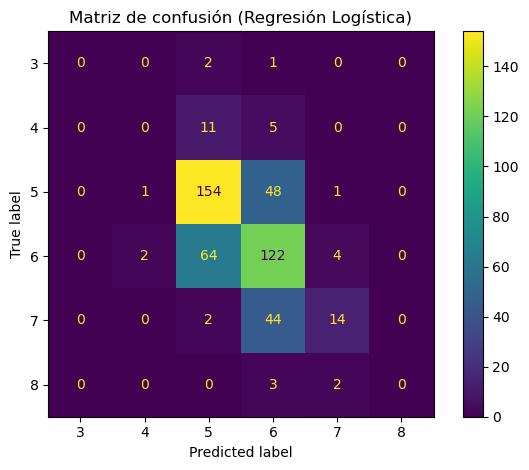

In [84]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Pipeline: preprocess + regresión logística (multiclase)
logreg_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=5000, solver="lbfgs"))
])

# Entrenar
logreg_pipe.fit(X_train, y_train)

# Predecir
y_pred = logreg_pipe.predict(X_test)

# Métricas (elige weighted para tener en cuenta desbalanceo de clases)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")
rec = recall_score(y_test, y_pred, average="weighted")

print(f"Accuracy (test): {acc:.4f}")
print(f"F1 weighted (test): {f1:.4f}")
print(f"Recall weighted (test): {rec:.4f}")

# Matriz de confusión
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
plt.figure(figsize=(7, 6))
disp.plot(values_format="d")
plt.title("Matriz de confusión (Regresión Logística)")
plt.tight_layout()
plt.show()


Podemos ver que tenemos una mala predicción de a que clase pertenece cada vino, podemos ver que el accuracy es bajo, pero es que además tenemos un mal F1 y podemos ver en la matriz de confusión que practicamente todos los vinos nos los clasifican como 5 o 6.

Ahora vamos a aplicar el método de KNN a ver como de preciso es y si mejora en algo a la regresión logística.

Accuracy (test): 0.5854
F1 weighted (test): 0.5676
Recall weighted (test): 0.5854


<Figure size 700x600 with 0 Axes>

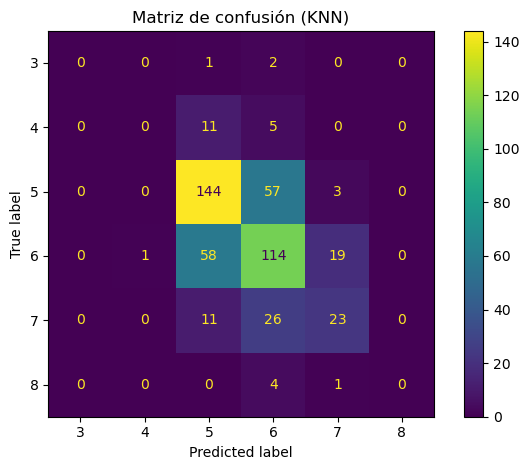

In [88]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Pipeline: preprocess + KNN
knn_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", KNeighborsClassifier(n_neighbors=5))  # cambia k si quieres
])

# Entrenar
knn_pipe.fit(X_train, y_train)

# Predecir
y_pred = knn_pipe.predict(X_test)

# Métricas (weighted por posible desbalanceo)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")
rec = recall_score(y_test, y_pred, average="weighted")

print(f"Accuracy (test): {acc:.4f}")
print(f"F1 weighted (test): {f1:.4f}")
print(f"Recall weighted (test): {rec:.4f}")

# Matriz de confusión
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
plt.figure(figsize=(7, 6))
disp.plot(values_format="d")
plt.title("Matriz de confusión (KNN)")
plt.tight_layout()
plt.show()


Podemos ver en este caso que KNN predice un poco peor que la regresión logística, esto se debe a que los auténticos 5 y 6's la logística nos los clasificaba más o menos bien y sin embargo esta los confunde mucho más y por eso es un poco peor. 

Vamos a pasar a ver un árbol de clasificación, pero lo vamos a ver con 5 de altura máxima para que pueda ser interpretable.

Accuracy (test): 0.5646
F1 weighted (test): 0.5359
Recall weighted (test): 0.5646


<Figure size 700x600 with 0 Axes>

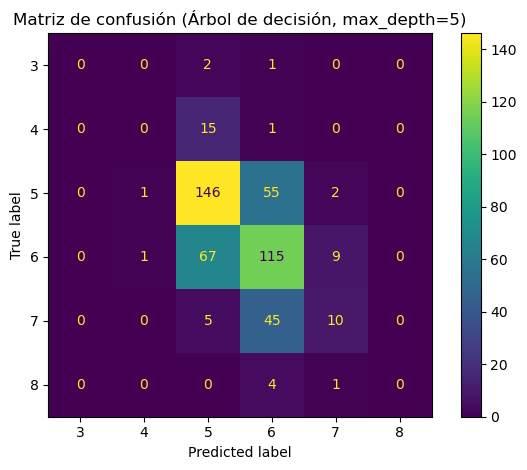

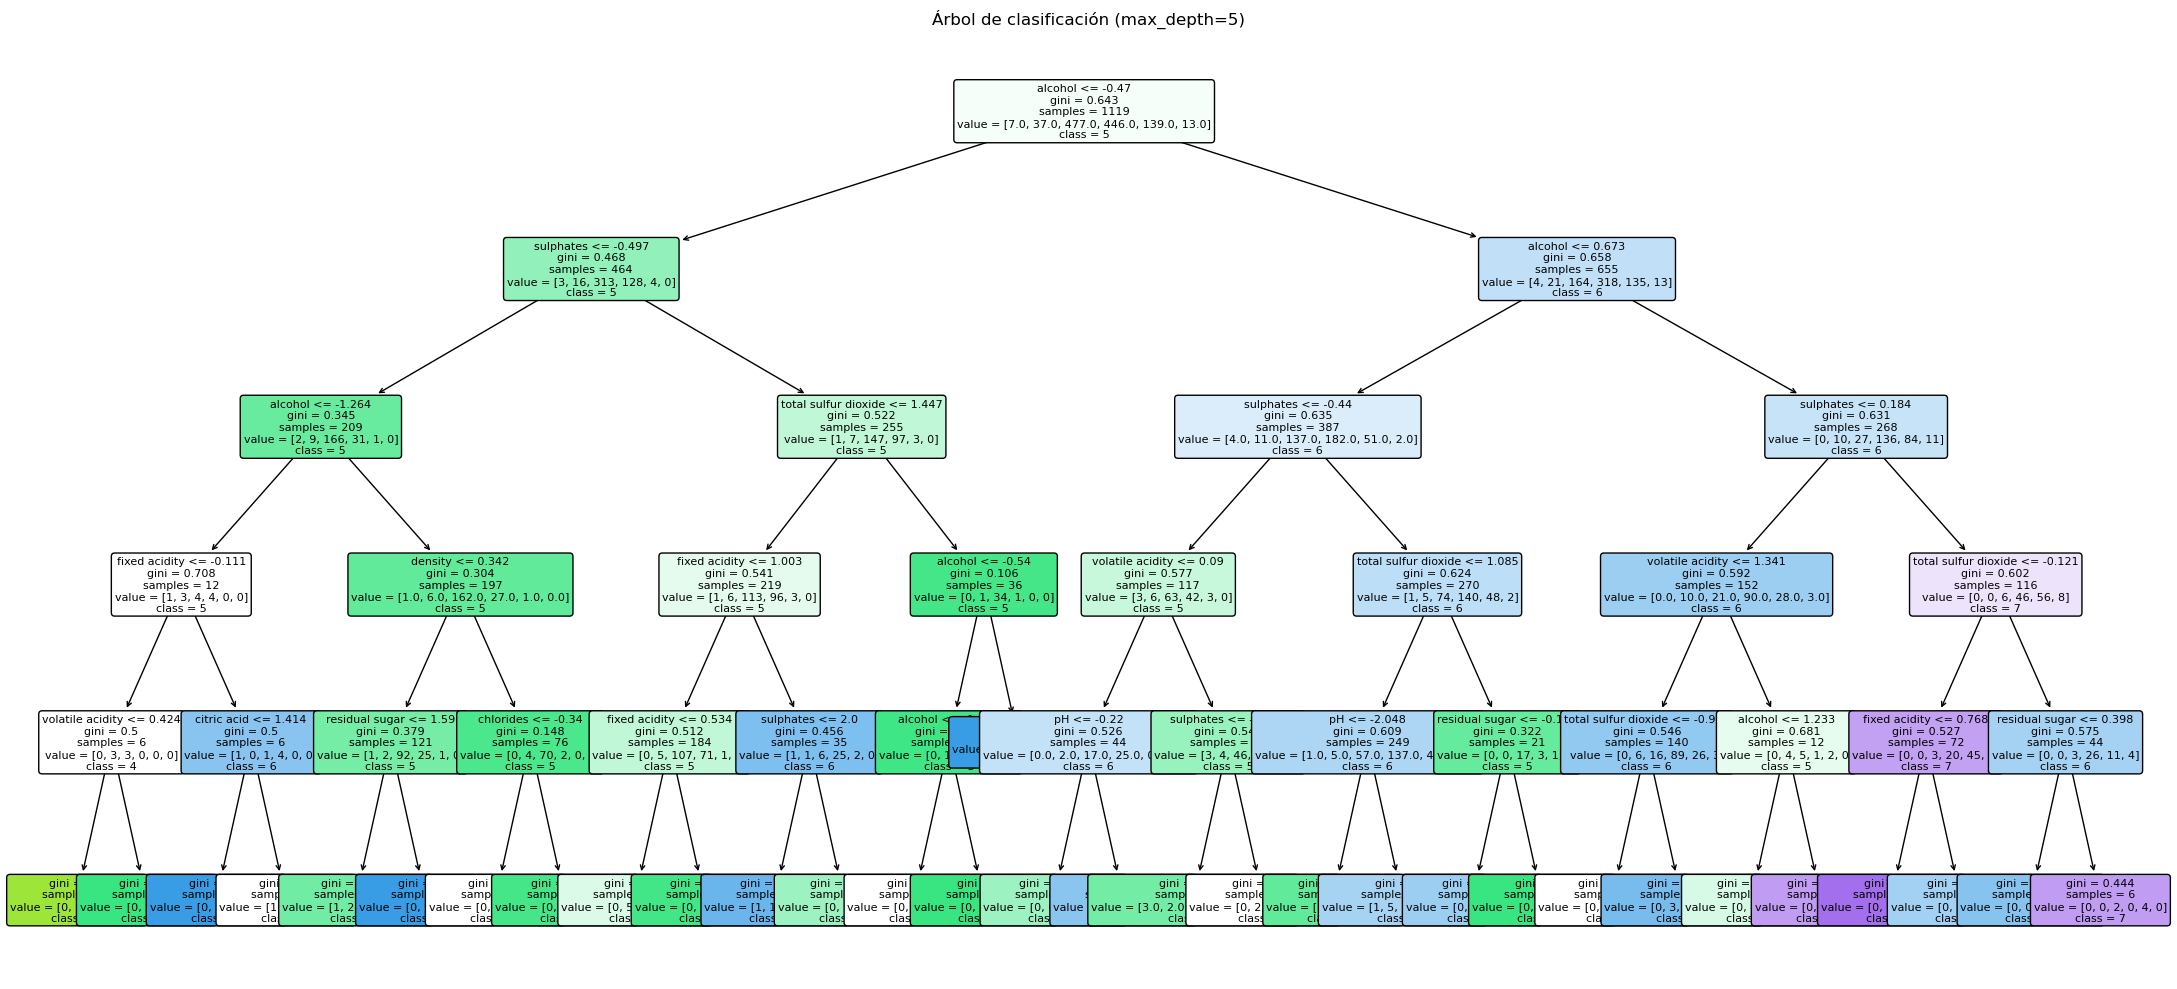

In [92]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Pipeline: preprocess + árbol (profundidad máxima 5)
tree_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(max_depth=5, random_state=42))
])

# Entrenar
tree_pipe.fit(X_train, y_train)

# Predecir
y_pred = tree_pipe.predict(X_test)

# Métricas (weighted)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")
rec = recall_score(y_test, y_pred, average="weighted")

print(f"Accuracy (test): {acc:.4f}")
print(f"F1 weighted (test): {f1:.4f}")
print(f"Recall weighted (test): {rec:.4f}")

# Matriz de confusión
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
plt.figure(figsize=(7, 6))
disp.plot(values_format="d")
plt.title("Matriz de confusión (Árbol de decisión, max_depth=5)")
plt.tight_layout()
plt.show()

# ----------------------------
# Plot del árbol
# ----------------------------
# Sacar nombres de features tras preprocess
pre = tree_pipe.named_steps["preprocess"]
num_feature_names = list(num_cols)

cat_feature_names = []
if len(cat_cols) > 0:
    ohe = pre.named_transformers_["cat"]
    cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()

feature_names = num_feature_names + cat_feature_names

clf = tree_pipe.named_steps["model"]

plt.figure(figsize=(22, 10))
plot_tree(
    clf,
    feature_names=feature_names,
    class_names=[str(c) for c in clf.classes_],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Árbol de clasificación (max_depth=5)")
plt.tight_layout()
plt.show()


Podemos ver que seguimos en el mismo ritmo que con KNN, este empeora bastante más, podemos ver que los parámetros de F1, accuracy y recall son más malos y la matriz de confusión es similar que la de KNN.

Ahora vamos a probar con los métodos de ensamble, el primero que vamos a usar es el bagging que permite bootstrap que es reemplazamiento, luego lo haremos con pasting que es sin reemplamiento.

Accuracy (test): 0.6042
F1 weighted (test): 0.5775
Recall weighted (test): 0.6042


<Figure size 700x600 with 0 Axes>

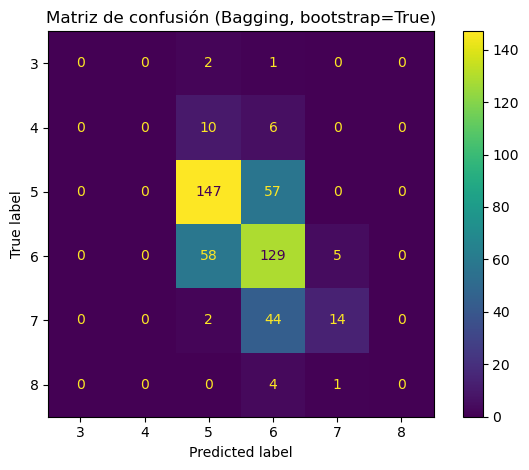

In [96]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Bagging (bootstrap = muestreo con reemplazamiento)
bag_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=5, random_state=42),
        n_estimators=200,
        bootstrap=True,        # <- CON reemplazamiento
        random_state=42,
        n_jobs=-1
    ))
])

# Entrenar
bag_pipe.fit(X_train, y_train)

# Predecir
y_pred = bag_pipe.predict(X_test)

# Métricas
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")
rec = recall_score(y_test, y_pred, average="weighted")

print(f"Accuracy (test): {acc:.4f}")
print(f"F1 weighted (test): {f1:.4f}")
print(f"Recall weighted (test): {rec:.4f}")

# Matriz de confusión
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
plt.figure(figsize=(7, 6))
disp.plot(values_format="d")
plt.title("Matriz de confusión (Bagging, bootstrap=True)")
plt.tight_layout()
plt.show()


Accuracy (test): 0.5646
F1 weighted (test): 0.5359
Recall weighted (test): 0.5646


<Figure size 700x600 with 0 Axes>

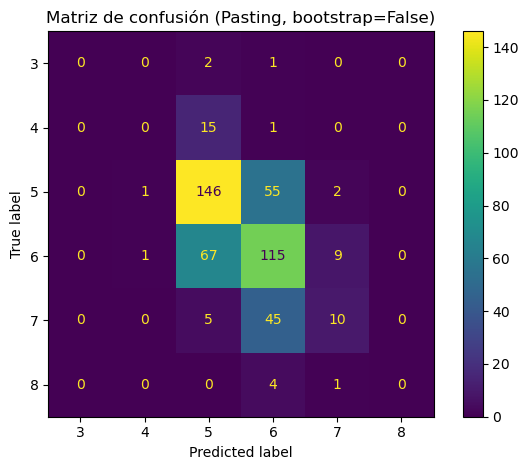

In [98]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Pasting = Bagging pero SIN reemplazamiento (bootstrap=False)
paste_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=5, random_state=42),
        n_estimators=200,
        bootstrap=False,       # <- SIN reemplazamiento (pasting)
        random_state=42,
        n_jobs=-1
    ))
])

# Entrenar
paste_pipe.fit(X_train, y_train)

# Predecir
y_pred = paste_pipe.predict(X_test)

# Métricas
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")
rec = recall_score(y_test, y_pred, average="weighted")

print(f"Accuracy (test): {acc:.4f}")
print(f"F1 weighted (test): {f1:.4f}")
print(f"Recall weighted (test): {rec:.4f}")

# Matriz de confusión
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
plt.figure(figsize=(7, 6))
disp.plot(values_format="d")
plt.title("Matriz de confusión (Pasting, bootstrap=False)")
plt.tight_layout()
plt.show()


Podemos ver que en el caso de Bagging si se consigue alcanzar a la regresión logística aun que simplemente por interpretabilidad nos seguiríamos quedando con la logística. Sin embargo podemos ver que pasting lo empeora por tanto ni se le tiene en cuenta.

Ahora vamos a probar otro método de ensamble que es el random forest, el cual hace muchos árboles de decisión y según lo que diga la mayoría clasifica, este tiene reemplazamiento por tanto hay alguna oportunidad de que nos mejore lo que tenemos.

Accuracy (test): 0.6625
F1 weighted (test): 0.6426
Recall weighted (test): 0.6625


<Figure size 700x600 with 0 Axes>

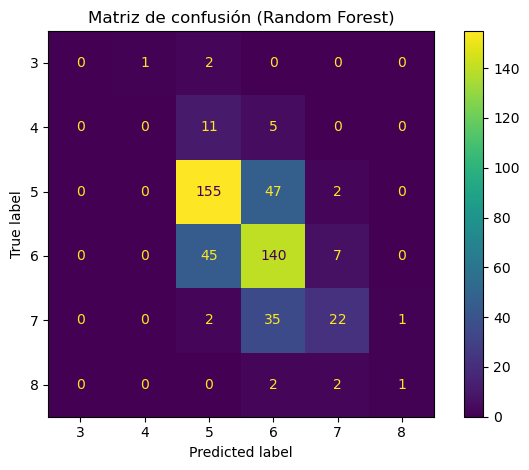

In [102]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

rf_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

# Entrenar
rf_pipe.fit(X_train, y_train)

# Predecir
y_pred = rf_pipe.predict(X_test)

# Métricas
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")
rec = recall_score(y_test, y_pred, average="weighted")

print(f"Accuracy (test): {acc:.4f}")
print(f"F1 weighted (test): {f1:.4f}")
print(f"Recall weighted (test): {rec:.4f}")

# Matriz de confusión
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
plt.figure(figsize=(7, 6))
disp.plot(values_format="d")
plt.title("Matriz de confusión (Random Forest)")
plt.tight_layout()
plt.show()


Y como he dicho, se mejora el modelo de clasificación, no mucho pero algo mejora, ahora deberíamos de plantearnos si esta mejora es lo suficientemente buena como para perder la interpretabilidad de la regresión logística y pasarnos a este método.

Ahora vamos a ver el modelo de Adaboost y el modelo de GradientBoosting, estos métodos se basan no en meter muchos predictores como en random forest, si no que van metiendo uno a uno y el siguiente intenta mejorar al anterior. Adaboost intenta que el siguiente predictor se fije en lo que ha hecho mal el anterior y lo mejore. Y Gradient Boosting hace lo mismo pero en vez de darle peso a los errores lo que hace es ajustar al nuevo predictor con los residuos del anterior.

C:\Users\MEDIA\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Accuracy (test): 0.4583
F1 weighted (test): 0.4353
Recall weighted (test): 0.4583


<Figure size 700x600 with 0 Axes>

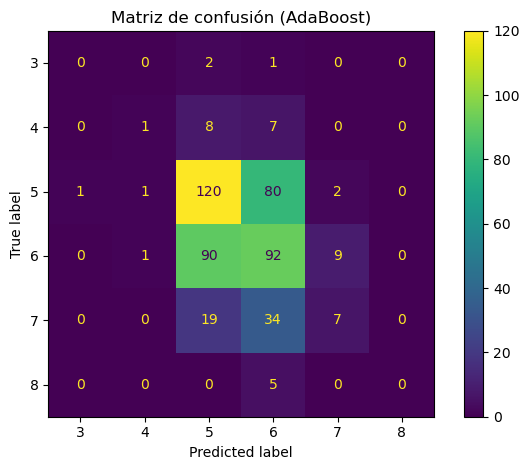

In [106]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

ada_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=2, random_state=42),
        n_estimators=300,
        learning_rate=0.1,
        random_state=42
    ))
])

# Entrenar
ada_pipe.fit(X_train, y_train)

# Predecir
y_pred = ada_pipe.predict(X_test)

# Métricas
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")
rec = recall_score(y_test, y_pred, average="weighted")

print(f"Accuracy (test): {acc:.4f}")
print(f"F1 weighted (test): {f1:.4f}")
print(f"Recall weighted (test): {rec:.4f}")

# Matriz de confusión
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
plt.figure(figsize=(7, 6))
disp.plot(values_format="d")
plt.title("Matriz de confusión (AdaBoost)")
plt.tight_layout()
plt.show()


Podemos ver que Adaboost empeora muchísmo, mcuho más que cualquiera que antes, esto se deberá a su propio funcionamiento de usar muchos predictores débiles.

Accuracy (test): 0.6458
F1 weighted (test): 0.6336
Recall weighted (test): 0.6458


<Figure size 700x600 with 0 Axes>

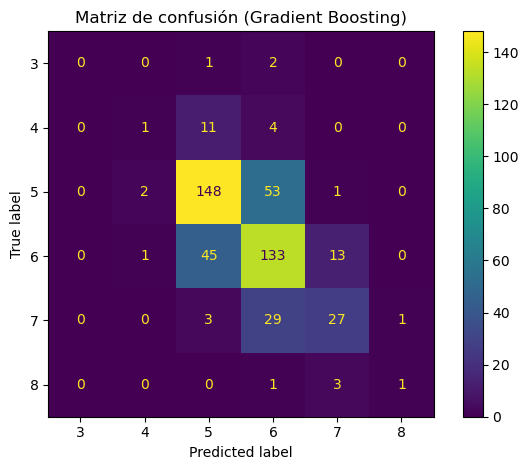

In [109]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

gb_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,        # profundidad de cada árbol base
        random_state=42
    ))
])

# Entrenar
gb_pipe.fit(X_train, y_train)

# Predecir
y_pred = gb_pipe.predict(X_test)

# Métricas
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")
rec = recall_score(y_test, y_pred, average="weighted")

print(f"Accuracy (test): {acc:.4f}")
print(f"F1 weighted (test): {f1:.4f}")
print(f"Recall weighted (test): {rec:.4f}")

# Matriz de confusión
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
plt.figure(figsize=(7, 6))
disp.plot(values_format="d")
plt.title("Matriz de confusión (Gradient Boosting)")
plt.tight_layout()
plt.show()


Ahora podemos ver sin embargo que Grdient Boosting se posiciona como el segundo mejor modelo en cuanto a la clasificación se refiere. Esta mejora se deberá a que este modelo se basa en ajustar los residuos y no darle peso a los errores como hace su análogo.

Ahora vamos a pasar a hacer técnicas de ML para intentar formar grupos etc.Primero vamos a comenzar con aprendizaje supervisado (PCA) y luego pasaremos a aprendizaje no supervisado con Clustering(K-means).

In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


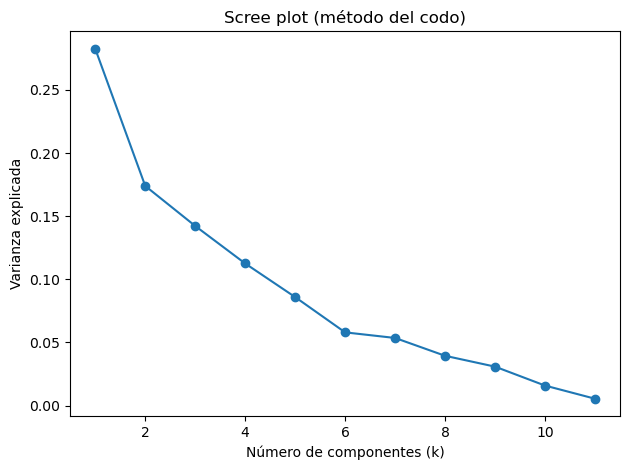

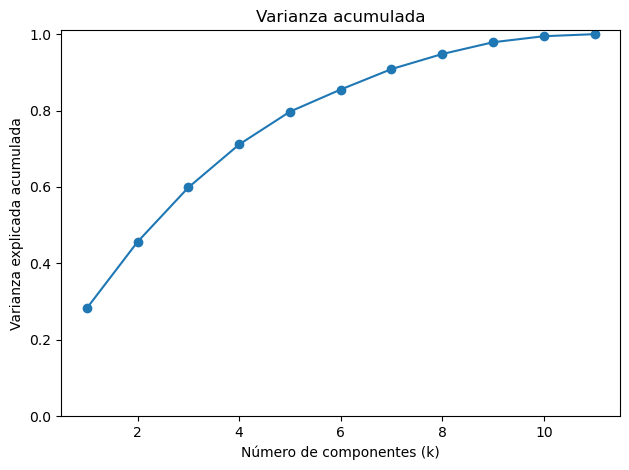

k mínimo para >= 95% varianza: 9
     k  explained_var  cum_explained_var
0    1       0.282543           0.282543
1    2       0.173937           0.456480
2    3       0.142241           0.598721
3    4       0.112517           0.711238
4    5       0.085904           0.797142
5    6       0.057953           0.855096
6    7       0.053516           0.908612
7    8       0.039392           0.948004
8    9       0.030799           0.978803
9   10       0.015806           0.994610
10  11       0.005390           1.000000


In [115]:
# --- Escalado (imprescindible para PCA) ---
scaler_pca = StandardScaler()
Xtr_s = scaler_pca.fit_transform(X_train)
Xte_s = scaler_pca.transform(X_test)

# --- PCA sin fijar k todavía ---
pca_full = PCA()
pca_full.fit(Xtr_s)

evr = pca_full.explained_variance_ratio_
cum_evr = np.cumsum(evr)

# Scree plot (codo)
plt.figure()
plt.plot(np.arange(1, len(evr) + 1), evr, marker="o")
plt.xlabel("Número de componentes (k)")
plt.ylabel("Varianza explicada")
plt.title("Scree plot (método del codo)")
plt.tight_layout()
plt.show()

# Varianza acumulada
plt.figure()
plt.plot(np.arange(1, len(cum_evr) + 1), cum_evr, marker="o")
plt.xlabel("Número de componentes (k)")
plt.ylabel("Varianza explicada acumulada")
plt.title("Varianza acumulada")
plt.ylim(0, 1.01)
plt.tight_layout()
plt.show()

# Heurística típica: mínimo k que explica al menos el 95%
k_95 = int(np.argmax(cum_evr >= 0.95) + 1)
print("k mínimo para >= 95% varianza:", k_95)

# (Opcional) imprimir tabla resumen
summary = pd.DataFrame({
    "k": np.arange(1, len(evr) + 1),
    "explained_var": evr,
    "cum_explained_var": cum_evr
})
print(summary.head(12))


Podemos ver en este caso que en la regla del codo se tiene que el codo está en 6 y cuando está en 6 podemos ver que se explica el 85% de la varianza que es un buen número, por tanto vamos ahora a ver las CP.

In [122]:
# Elige k: puedes usar k_95 o el que veas por "codo" en el scree plot
k = 6  # cámbialo si quieres, por ejemplo k = 5

pca = PCA(n_components=k)
Xtr_pca = pca.fit_transform(Xtr_s)
Xte_pca = pca.transform(Xte_s)

feature_names = list(X_train.columns)

# Loadings: (n_features x k)
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=[f"PC{i+1}" for i in range(k)]
)

print("Varianza explicada por componente:")
for i, v in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"PC{i}: {v:.4f}")

print("\nLoadings (primeras filas):")
print(loadings.head())

# Top variables por componente
top_n = 5
for j in range(k):
    pc = f"PC{j+1}"
    top_vars = loadings[pc].abs().sort_values(ascending=False).head(top_n).index
    print(f"\nTop {top_n} variables en {pc} (por |loading|):")
    print(loadings.loc[top_vars, pc].sort_values(key=np.abs, ascending=False))


Varianza explicada por componente:
PC1: 0.2825
PC2: 0.1739
PC3: 0.1422
PC4: 0.1125
PC5: 0.0859
PC6: 0.0580

Loadings (primeras filas):
                       PC1       PC2       PC3       PC4       PC5       PC6
fixed acidity     0.481446 -0.126642 -0.131598 -0.241538 -0.100405  0.111681
volatile acidity -0.227482  0.302747 -0.439650  0.024828  0.243113  0.443358
citric acid       0.463515 -0.170030  0.225994 -0.089991 -0.065341  0.062970
residual sugar    0.151564  0.235560  0.147987 -0.394813  0.733457 -0.001798
chlorides         0.222408  0.143949 -0.120773  0.633872  0.295750  0.257050

Top 5 variables en PC1 (por |loading|):
fixed acidity    0.481446
citric acid      0.463515
pH              -0.440778
density          0.395935
sulphates        0.250073
Name: PC1, dtype: float64

Top 5 variables en PC2 (por |loading|):
total sulfur dioxide    0.563180
free sulfur dioxide     0.498373
alcohol                -0.408329
volatile acidity        0.302747
residual sugar          0.235560


Podemos ver que que la primera CP podríamos interpretarla como la acidez del vino ya que tenemos que si suben las variables que tienen que ver con la acidez baja el PH, y podemos ver que la segunda CP separa vinos con más SO2 de vinos con más alcohol.

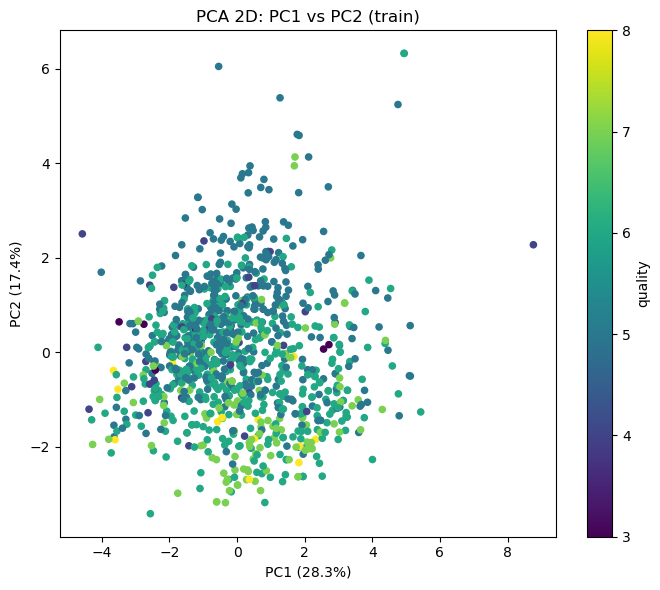

In [124]:
# Asegurar que hay al menos 2 componentes
if k < 2:
    print("Necesitas k >= 2 para graficar en 2D.")
else:
    # Codificar clases para colorear
    y_vals = np.array(y_train)
    classes = np.unique(y_vals)
    class_to_int = {c: i for i, c in enumerate(classes)}
    y_int = np.array([class_to_int[c] for c in y_vals])

    plt.figure(figsize=(7, 6))
    sc = plt.scatter(Xtr_pca[:, 0], Xtr_pca[:, 1], c=y_int, s=20)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    plt.title("PCA 2D: PC1 vs PC2 (train)")

    cbar = plt.colorbar(sc)
    cbar.set_ticks(range(len(classes)))
    cbar.set_ticklabels([str(c) for c in classes])
    cbar.set_label("quality")

    plt.tight_layout()
    plt.show()


Como era de esperar, con solo dos CP que explican solo un 40% de la información no podemos sacar nada visualmente.

Accuracy (test): 0.6146
F1 weighted (test): 0.5864
Recall weighted (test): 0.6146


<Figure size 700x600 with 0 Axes>

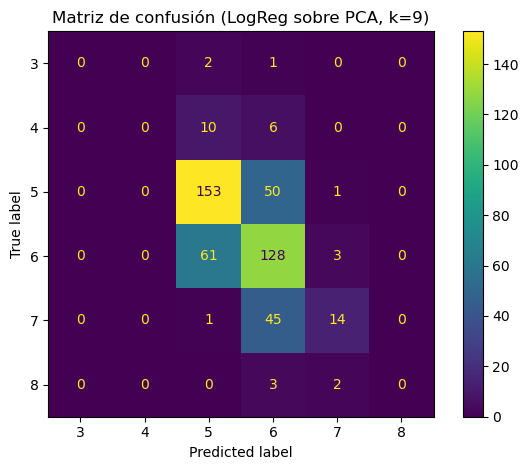

In [130]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, recall_score

k = k_95  # <-- pon aquí el k que hayas elegido con el codo (o k_95)

pca_clf = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=k, random_state=42)),
    ("clf", LogisticRegression(max_iter=5000, solver="lbfgs"))
])

# Entrenar con train (solo X) y predecir en test
pca_clf.fit(X_train, y_train)
y_pred = pca_clf.predict(X_test)

# Métricas
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")
rec = recall_score(y_test, y_pred, average="weighted")

print(f"Accuracy (test): {acc:.4f}")
print(f"F1 weighted (test): {f1:.4f}")
print(f"Recall weighted (test): {rec:.4f}")

# Matriz de confusión
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
plt.figure(figsize=(7, 6))
disp.plot(values_format="d")
plt.title(f"Matriz de confusión (LogReg sobre PCA, k={k})")
plt.tight_layout()
plt.show()


Podemos ver que en este caso usando PCA tampoco se mejora mucho la predicción de nuevas observaciones.

Ahora vamos a pasar a hacer el K-means, a ver que nos dice la máquina sobre que grupos observa ella.

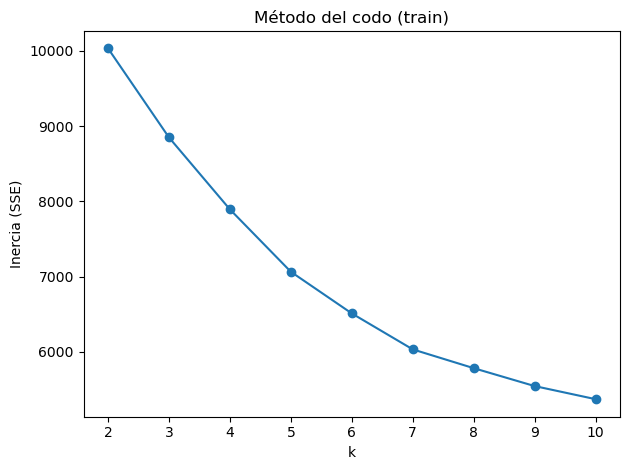

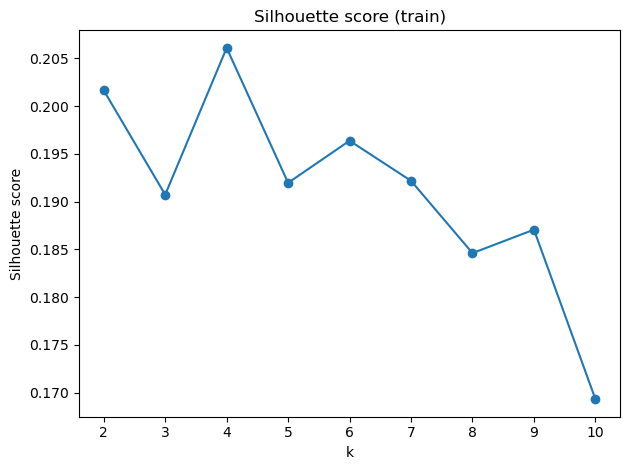

Mejor k por silhouette: 4


In [134]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 11)

inertias = []
silhouettes = []

# Estandarizar + KMeans (PCA opcional, aquí no)
Xtr_s = StandardScaler().fit_transform(X_train)

for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(Xtr_s)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(Xtr_s, labels))

# Codo (inercia)
plt.figure()
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inercia (SSE)")
plt.title("Método del codo (train)")
plt.tight_layout()
plt.show()

# Silhouette
plt.figure()
plt.plot(list(k_values), silhouettes, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("Silhouette score (train)")
plt.tight_layout()
plt.show()

best_k_sil = list(k_values)[int(np.argmax(silhouettes))]
print("Mejor k por silhouette:", best_k_sil)


Accuracy (test): 0.3021
F1 weighted (test): 0.3227
Recall weighted (test): 0.3021


<Figure size 700x600 with 0 Axes>

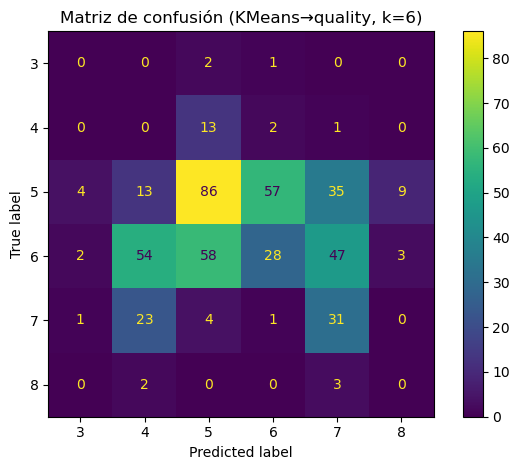

In [138]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, f1_score, recall_score
from scipy.optimize import linear_sum_assignment

# Usa el k que quieras (por ejemplo best_k_sil)
k = 6

# Fit en train
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(X_train)
Xte_s = scaler.transform(X_test)

km = KMeans(n_clusters=k, n_init=10, random_state=42)
cluster_train = km.fit_predict(Xtr_s)
cluster_test = km.predict(Xte_s)

# --- Alinear clusters con etiquetas reales usando train ---
# Convertimos y_train/y_test a valores (por si son category)
ytr = np.array(y_train)
yte = np.array(y_test)

true_classes = np.unique(ytr)
# matriz de contingencia: filas=clase real, cols=cluster
cont = confusion_matrix(ytr, cluster_train, labels=true_classes)

# asignación óptima maximizando aciertos
row_ind, col_ind = linear_sum_assignment(-cont)

# mapeo cluster -> clase
cluster_to_class = {cluster: true_classes[row] for row, cluster in zip(row_ind, col_ind)}

# predicción de clase a partir de cluster en test
y_pred_test = np.array([cluster_to_class.get(c, true_classes[0]) for c in cluster_test])

# Métricas (weighted por desbalanceo)
acc = accuracy_score(yte, y_pred_test)
f1 = f1_score(yte, y_pred_test, average="weighted")
rec = recall_score(yte, y_pred_test, average="weighted")

print(f"Accuracy (test): {acc:.4f}")
print(f"F1 weighted (test): {f1:.4f}")
print(f"Recall weighted (test): {rec:.4f}")

# Matriz de confusión (clases reales vs clases predichas por clustering)
labels_sorted = sorted(np.unique(yte))
cm = confusion_matrix(yte, y_pred_test, labels=labels_sorted)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[str(x) for x in labels_sorted])
plt.figure(figsize=(7, 6))
disp.plot(values_format="d")
plt.title(f"Matriz de confusión (KMeans→quality, k={k})")
plt.tight_layout()
plt.show()


Podemos ver que en este caso el aprendizaje no supervisado no vale para nada, se equivoca en todo prácticamente, primero según shil k=4 lo cual no es cierto, ya que k es 6, y aun poniendo k = 6 sigue fallando mucho el modelo.